In [419]:
# Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [420]:
# ==========================================
# 1 - Data Understanding
# ==========================================

In [421]:
import pandas as pd

data = pd.read_csv("used_cars.csv")
df = data.copy()

df.head(15)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
5,Acura,ILX 2.4L,2016,"136,397 mi.",Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,NaN,"$14,798"
6,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,"$31,000"
7,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,"$7,300"
8,Lexus,RC 350 F Sport,2021,"23,436 mi.",Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,"$41,927"
9,Tesla,Model X Long Range Plus,2020,"34,000 mi.",NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes,"$69,950"


In [422]:
# Random Data
df.sample(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
1639,Nissan,Titan S,2017,"20,220 mi.",Gasoline,390.0HP 5.6L 8 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Gray,None reported,Yes,"$32,324"
102,Lexus,LC 500 Base,2020,"37,869 mi.",Gasoline,5.0L V8 32V PDI DOHC,10-Speed Automatic,Atomic Silver,Rioja Red,None reported,NaN,"$75,950"
121,Toyota,Corolla LE,2010,"72,348 mi.",Gasoline,132.0HP 1.8L 4 Cylinder Engine Gasoline Fuel,A/T,Red,Gray,At least 1 accident or damage reported,Yes,"$9,995"
3709,Ford,Mustang Mach-E Select,2021,"18,000 mi.",NaN,266.0HP Electric Motor Electric Fuel System,A/T,Blue,Black,None reported,Yes,"$39,499"
3905,Nissan,GT-R Premium,2013,"101,000 mi.",Gasoline,545.0HP 3.8L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,White,Black,None reported,Yes,"$59,000"


In [423]:
# size of the dataset
df.shape

(4009, 12)

In [424]:
# Data Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [425]:

df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='str')

In [426]:
# Check Description of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
model_year,4009.0,2015.51559,6.104816,1974.0,2012.0,2017.0,2020.0,2024.0


In [427]:
# Number of unique values in each column
df.nunique()

brand             57
model           1898
model_year        34
milage          2818
fuel_type          7
engine          1146
transmission      62
ext_col          319
int_col          156
accident           2
clean_title        1
price           1569
dtype: int64

In [428]:
# Check Balance of a categorical column 
df['fuel_type'].value_counts()

fuel_type
Gasoline          3309
Hybrid             194
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

In [429]:
# Check Balance of the dataset in percentages
round(df['fuel_type'].value_counts(normalize=True)*100, 2)

fuel_type
Gasoline          86.19
Hybrid             5.05
E85 Flex Fuel      3.62
Diesel             3.02
–                  1.17
Plug-In Hybrid     0.89
not supported      0.05
Name: proportion, dtype: float64

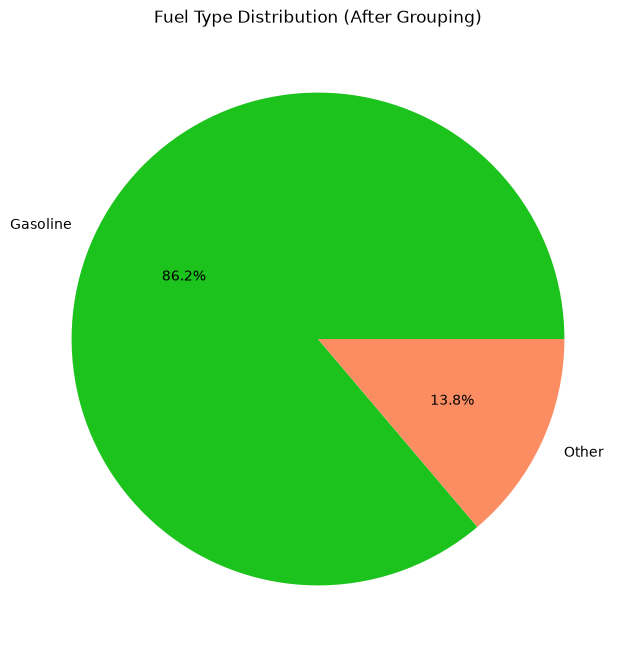

In [430]:
# ==========================================
# Handling Rare Categories in Features (Fuel Type)
# ==========================================

fuel_percentages = df['fuel_type'].value_counts(normalize=True) * 100

rare_fuels = fuel_percentages[fuel_percentages < 10].index

df['fuel_type'] = df['fuel_type'].replace(rare_fuels, 'Other')

plt.figure(figsize=(8, 8))
df['fuel_type'].value_counts().plot.pie(autopct='%1.1f%%', colors=["#1cc31c", '#fc8d62'])
plt.title('Fuel Type Distribution (After Grouping)')
plt.ylabel('') 
plt.show()

In [431]:
 # ==========================================
# 2. DATA CLEANING & PREPROCESSING
# ==========================================

In [432]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",Other,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Other,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [433]:
missing_percentage = df['fuel_type'].isna().mean() * 100
print(f"Missing values: {missing_percentage:.2f}%")

Missing values: 4.24%


In [434]:

df['price'] = df['price'].astype(str).str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')


df['milage'] = df['milage'].astype(str).str.replace(' mi.', '', regex=False)
df['milage'] = df['milage'].str.replace(',', '', regex=False)
df['milage'] = pd.to_numeric(df['milage'], errors='coerce')
    

df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode()[0])


df['accident'] = df['accident'].fillna('Unknown')
df['clean_title'] = df['clean_title'].fillna('Unknown')


df = df.drop_duplicates()


print("first 5 rows after cleaning:")
display(df.head())

print("\nData information to ensure columns are converted to numbers(float/int):")
df.info()

first 5 rows after cleaning:


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,Other,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Unknown,54598
3,INFINITI,Q50 Hybrid Sport,2015,88900,Other,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Unknown,34999



Data information to ensure columns are converted to numbers(float/int):
<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   int64
 4   fuel_type     4009 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      4009 non-null   str  
 10  clean_title   4009 non-null   str  
 11  price         4009 non-null   int64
dtypes: int64(3), str(9)
memory usage: 376.0 KB


In [435]:
df.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

In [436]:
# 3. Detect and Remove Duplicate Rows
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 0


In [437]:
# ==========================================
# Exploratory Data Analysis (EDA)
# =======================================

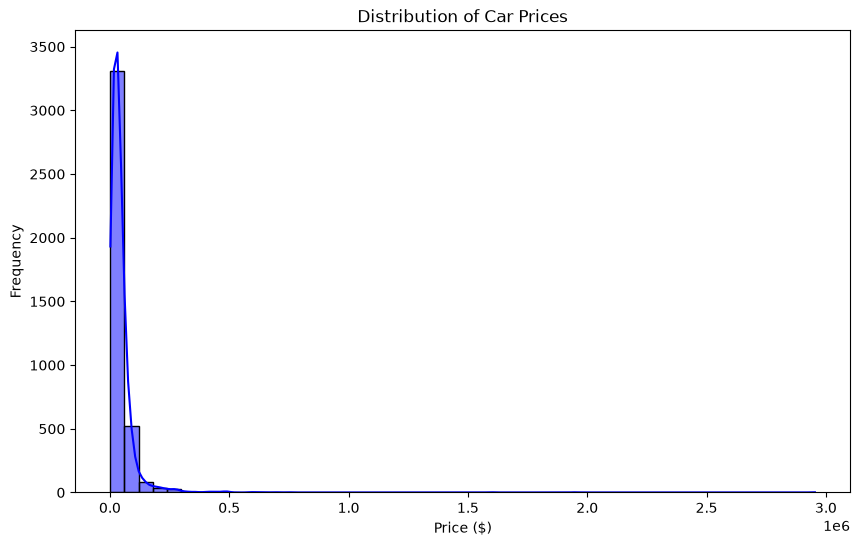

In [438]:
# 1. Distribution of Car Prices
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True, color='blue')
plt.title('Distribution of Car Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

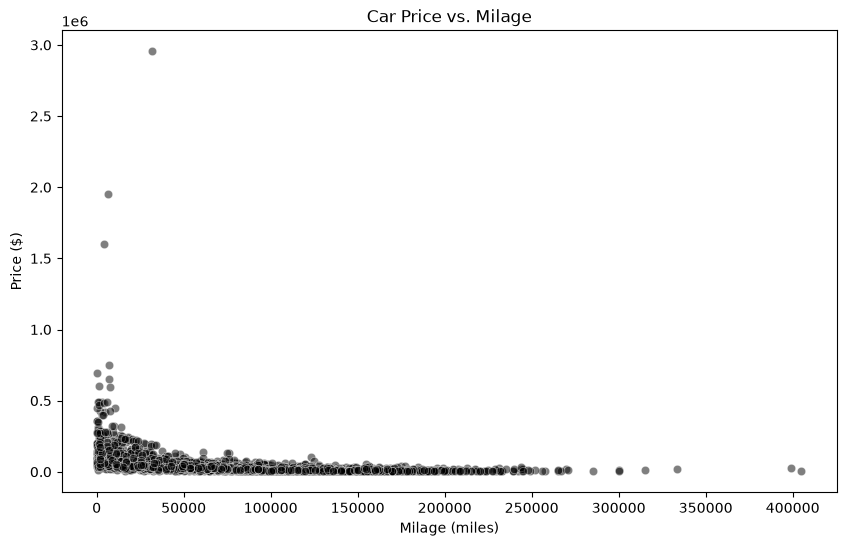

In [439]:
# 2. Scatter plot: Milage vs Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='milage', y='price', data=df, alpha=0.5, color='black')
plt.title('Car Price vs. Milage')
plt.xlabel('Milage (miles)')
plt.ylabel('Price ($)')
plt.show()

C:\Users\Ziad\AppData\Local\Temp\ipykernel_27600\1456210023.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fuel_type', y='price', data=df, palette='Set2',showfliers=False)


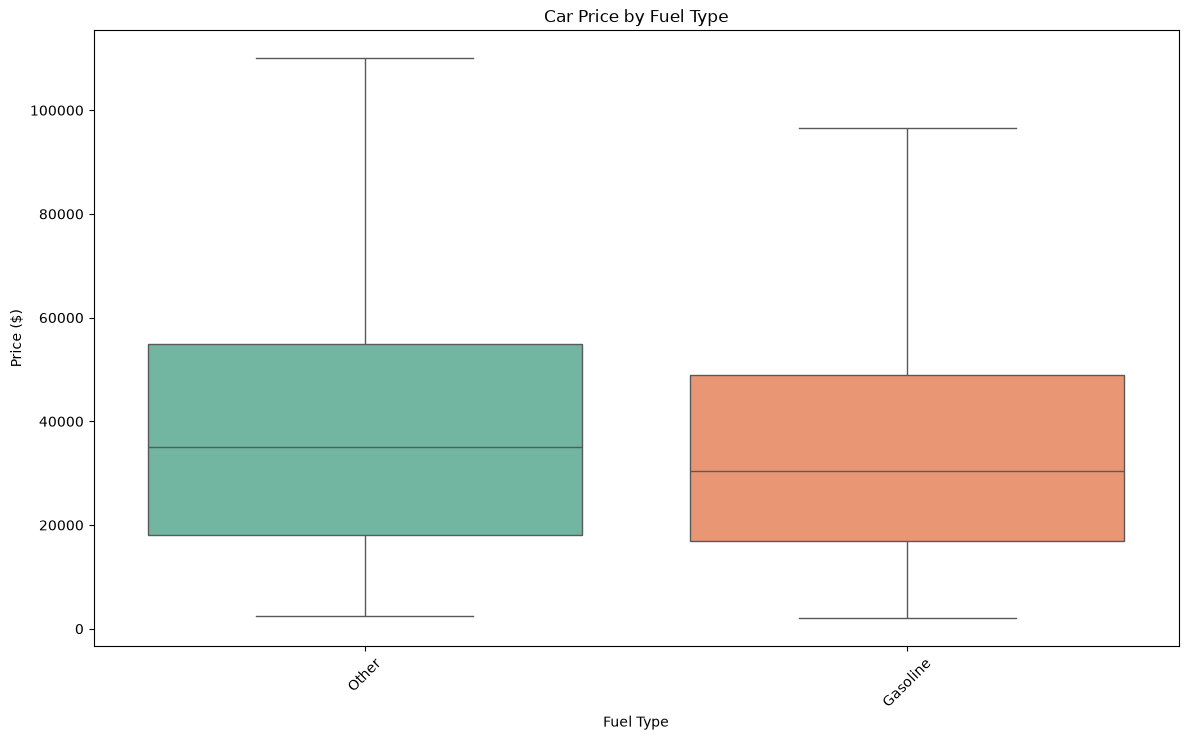

In [440]:
# 3. Boxplot: Fuel Type vs Price
plt.figure(figsize=(14, 8))
sns.boxplot(x='fuel_type', y='price', data=df, palette='Set2',showfliers=False)
plt.title('Car Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price ($)')
plt.xticks(rotation=45) 
plt.show()

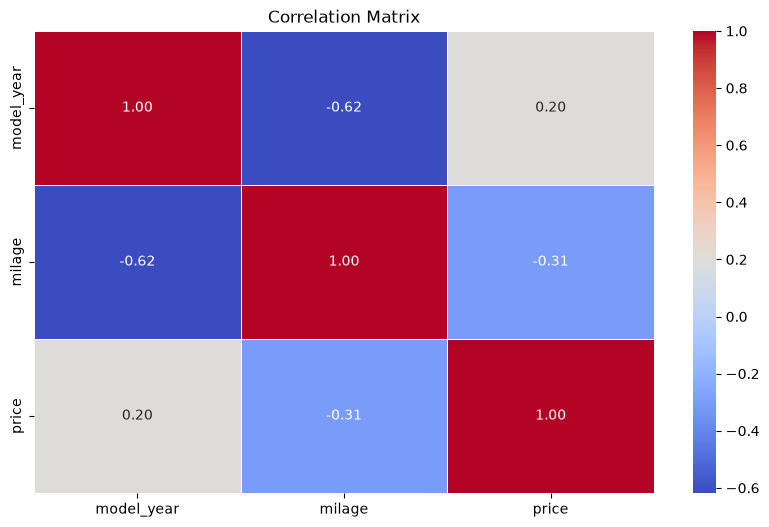

In [441]:
# 4. Correlation Heatmap
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

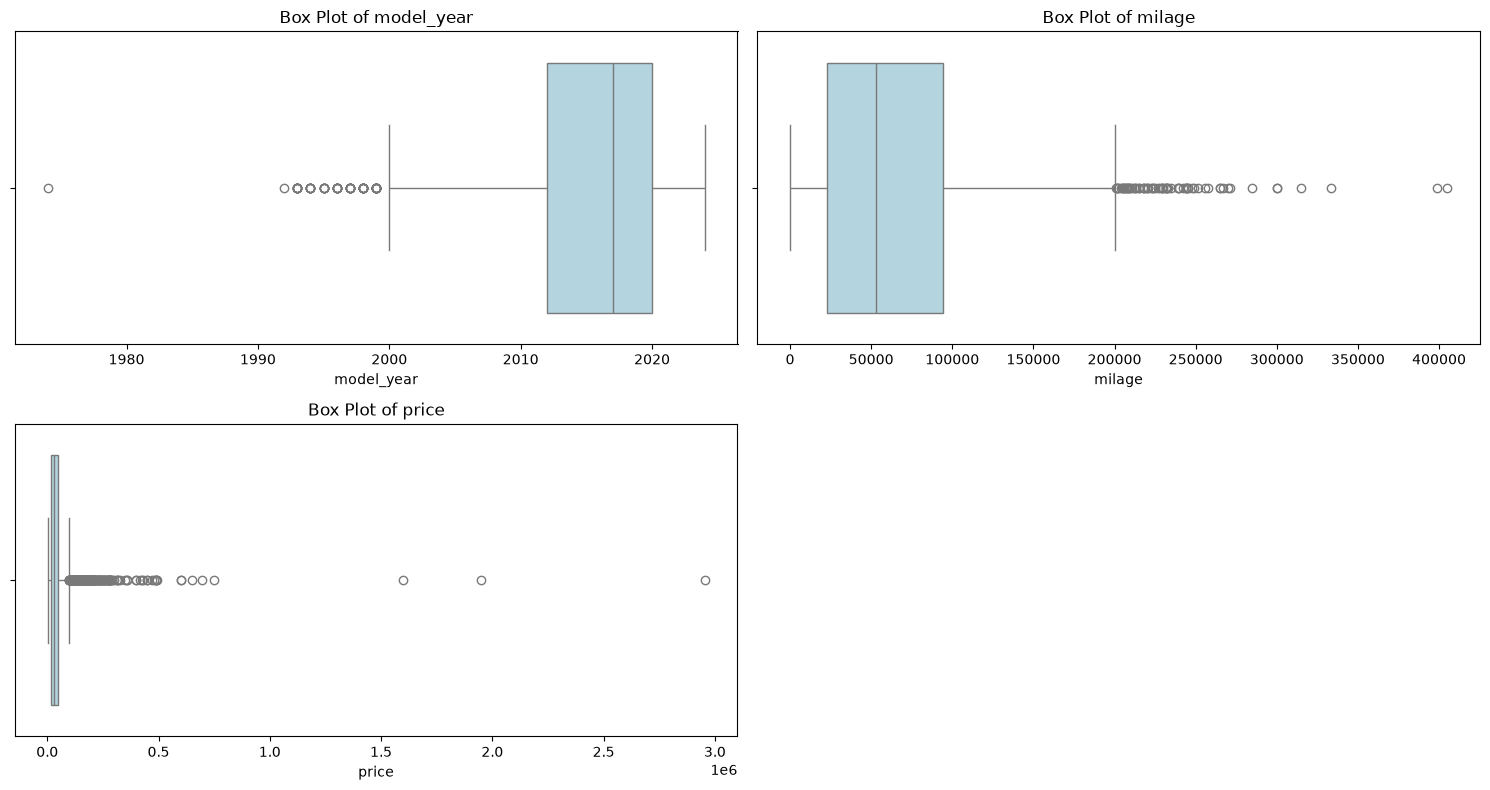

In [442]:
# 5. Check Outliers for all numeric columns
import math

# Extract numeric columns only
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

cols = 2
rows = math.ceil(len(num_cols) / cols) 

plt.figure(figsize=(15, rows * 4))

for i, feature in enumerate(num_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x=df[feature], color='lightblue')
    plt.title(f"Box Plot of {feature}")

plt.tight_layout()
plt.show()

C:\Users\Ziad\AppData\Local\Temp\ipykernel_27600\788667161.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette='viridis')


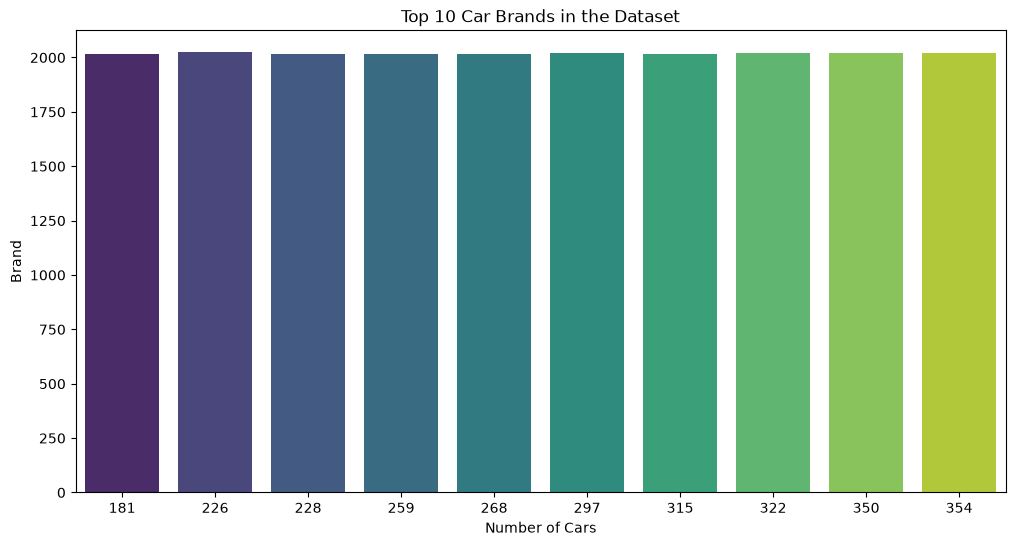

In [443]:
# 6. Top 10 Car Brands in the dataset
plt.figure(figsize=(12, 6))
top_brands = df['model_year'].value_counts().head(10)

sns.barplot(x=top_brands.values, y=top_brands.index, palette='viridis')
plt.title('Top 10 Car Brands in the Dataset')
plt.xlabel('Number of Cars')
plt.ylabel('Brand')
plt.show()

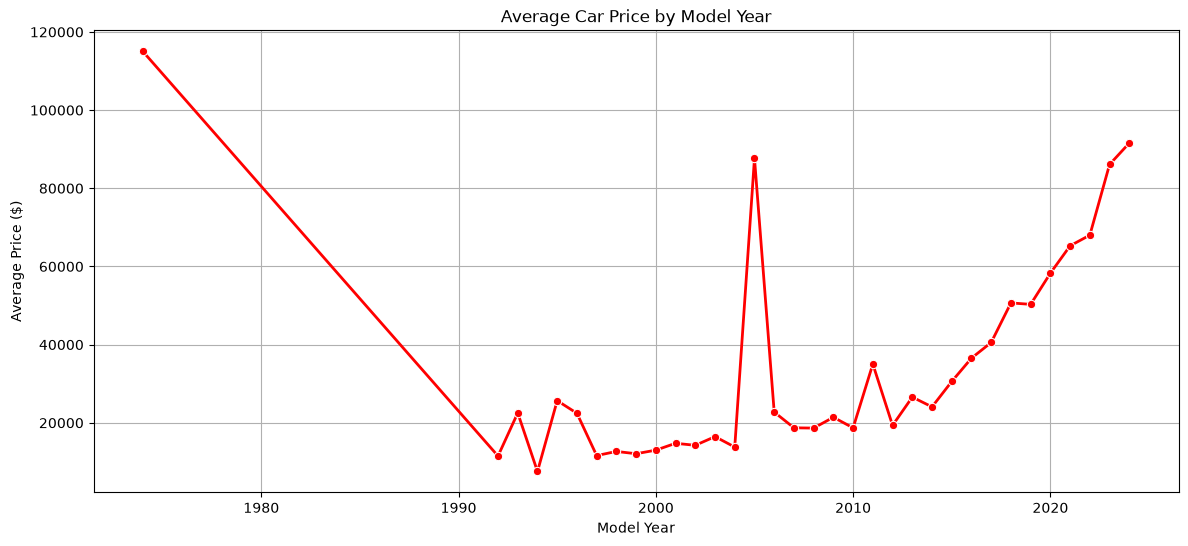

In [444]:
# 7. Average Price by Model Year
plt.figure(figsize=(14, 6))

# Calculate average price for each year
avg_price_year = df.groupby('model_year')['price'].mean().reset_index()

sns.lineplot(x='model_year', y='price', data=avg_price_year, marker='o', color='red', linewidth=2)
plt.title('Average Car Price by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Average Price ($)')
plt.grid(True)
plt.show()

In [445]:
# ==========================================
# Data Preprocessing
# ==========================================

In [446]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   int64
 4   fuel_type     4009 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      4009 non-null   str  
 10  clean_title   4009 non-null   str  
 11  price         4009 non-null   int64
dtypes: int64(3), str(9)
memory usage: 376.0 KB


In [447]:
df.head(1)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,Other,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300


In [448]:
# ==========================================
#            (Missing Values)
# ==========================================

print("Missing values before cleaning:\n", df.isnull().sum())

df_model = df.dropna().copy()

print(f"Data shape after handling missing values: {df_model.shape}")

Missing values before cleaning:
 brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64
Data shape after handling missing values: (4009, 12)


In [449]:
# ==========================================
# 1. Encoding Categorical Variables
# ==========================================

from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

encoder = LabelEncoder()

for col in df_model.select_dtypes(include="object").columns:
    df_model[col] = encoder.fit_transform(df_model[col].astype(str))

print("Dataset Shape:", df_model.shape)
df_model.head(3)

Dataset Shape: (4009, 12)


C:\Users\Ziad\AppData\Local\Temp\ipykernel_27600\4162478001.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_model.select_dtypes(include="object").columns:


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,14,1743,2013,51000,1,581,16,29,14,0,1,10300
1,19,1182,2021,34742,0,566,32,185,71,0,1,38005
2,27,1325,2022,22372,0,541,40,38,14,1,0,54598


In [450]:
# ==========================================
# 2. Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X = df_model.drop("price", axis=1)
y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (3207, 11)
Test Shape : (802, 11)


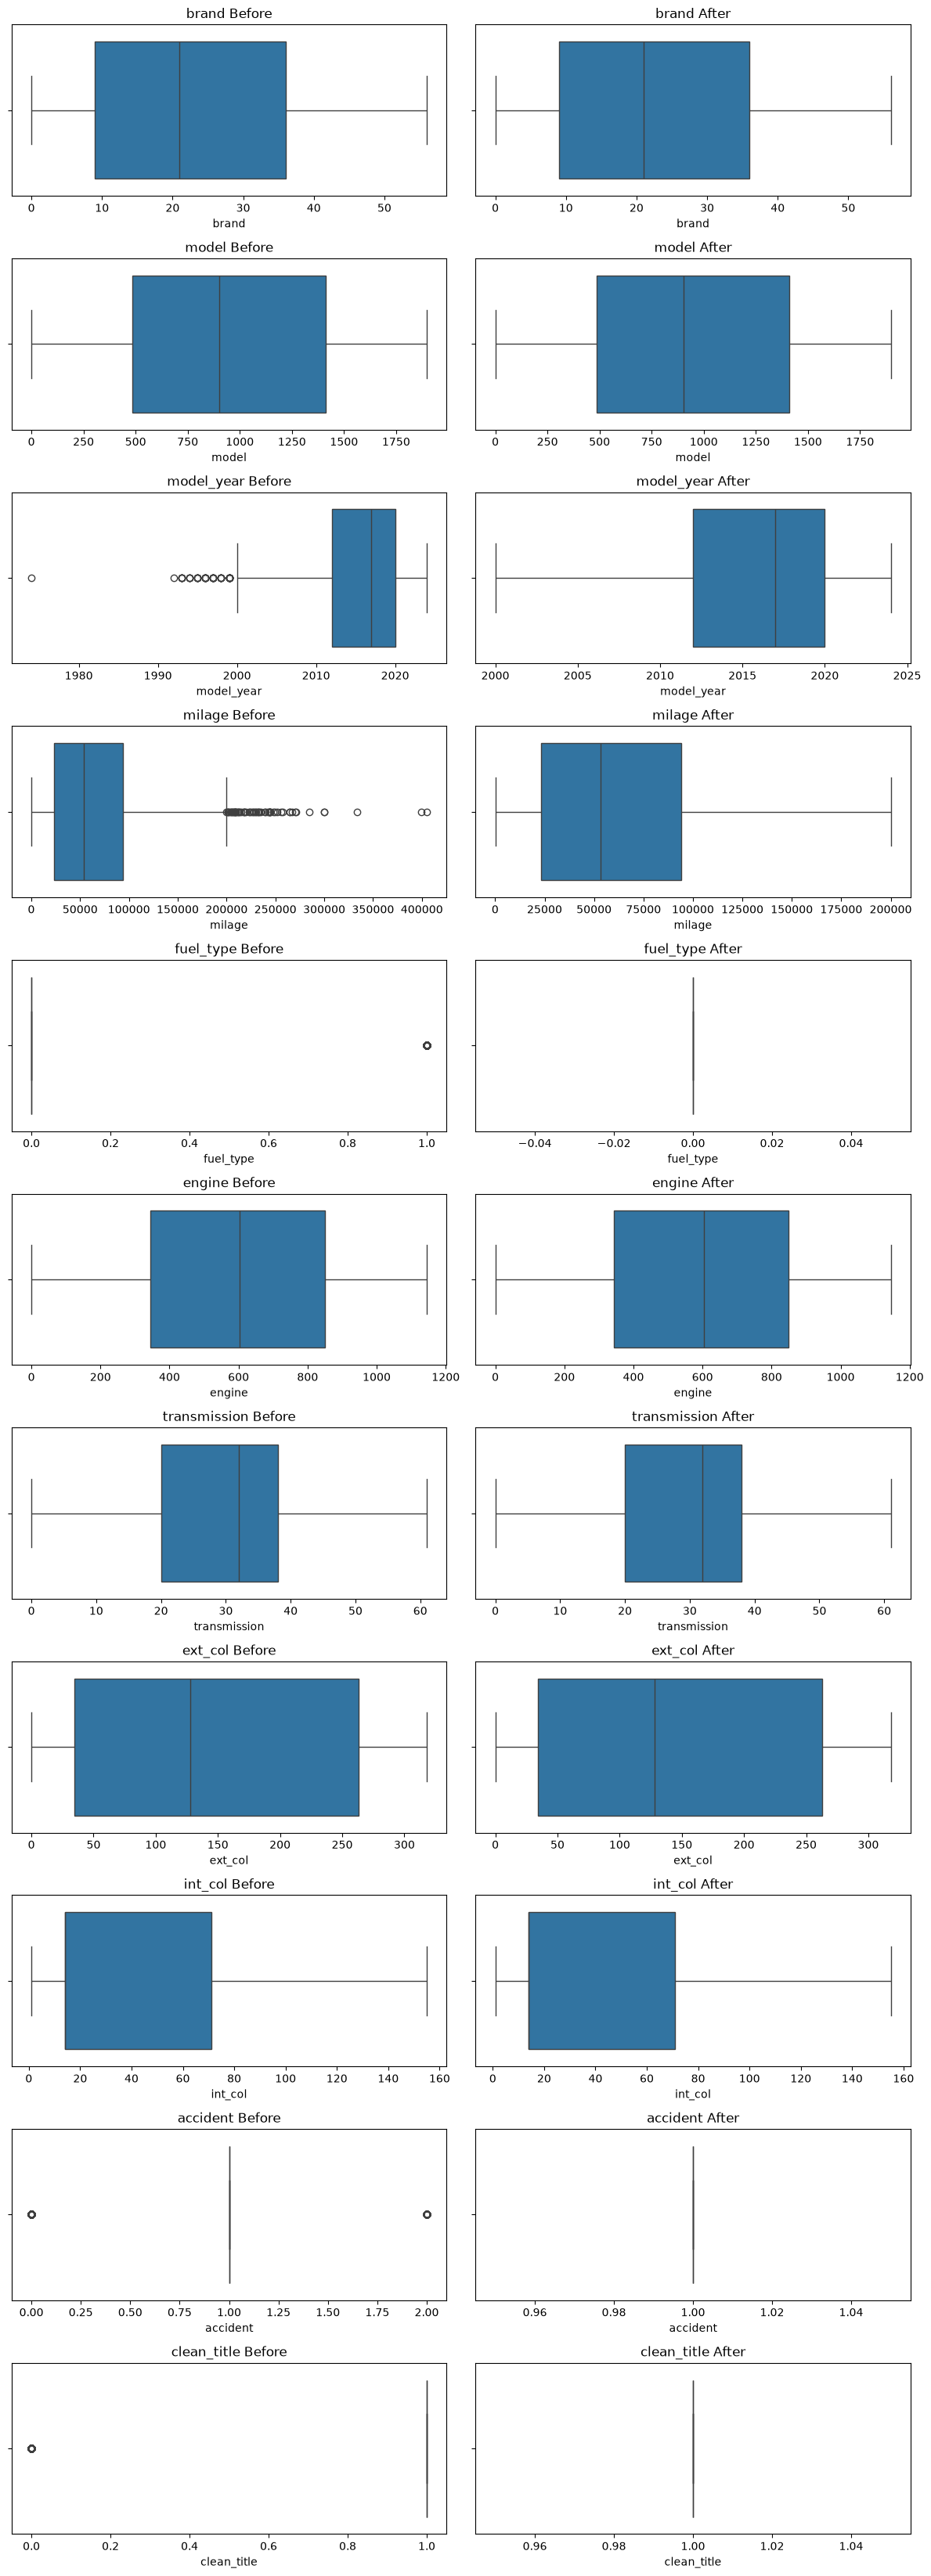

In [451]:
# ==========================================
# 3. Outlier Treatment
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = X_train.select_dtypes(include="number").columns

X_train_capped = X_train.copy()
X_test_capped = X_test.copy()

for col in numeric_cols:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_train_capped[col] = X_train[col].clip(lower, upper)
    X_test_capped[col] = X_test[col].clip(lower, upper)

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, len(numeric_cols)*3))

for i, col in enumerate(numeric_cols):

    sns.boxplot(x=X_train[col], ax=axes[i,0])
    axes[i,0].set_title(f"{col} Before")

    sns.boxplot(x=X_train_capped[col], ax=axes[i,1])
    axes[i,1].set_title(f"{col} After")

plt.tight_layout()
plt.show()

In [452]:
!pip install imbalanced-learn

In [453]:
# ==========================================
# 5. Feature Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print("Train:", X_train_scaled.shape)
print("Test :", X_test_scaled.shape)

X_train_scaled.describe().round(2)

Train: (3207, 11)
Test : (802, 11)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
count,3207.00,3207.00,3207.00,3207.00,3207.00,3207.00,3207.00,3207.00,3207.00,3207.00,3207.00
mean,-0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.45,-1.69,-6.89,-1.24,-0.40,-1.97,-2.09,-1.40,-0.88,-1.65,-2.41
25%,-0.89,-0.81,-0.59,-0.79,-0.40,-0.84,-0.75,-1.09,-0.59,0.45,0.41
50%,-0.15,-0.05,0.24,-0.22,-0.40,0.02,0.05,-0.26,-0.59,0.45,0.41
75%,0.77,0.87,0.74,0.55,-0.40,0.83,0.45,0.94,0.71,0.45,0.41
max,2.00,1.75,1.40,6.49,2.52,1.80,1.99,1.43,2.61,2.56,0.41


In [454]:
# ----------------------------------------
# 5) - Build and Train Models
# ----------------------------------------

In [455]:
# ==========================================
# 6.1 Cross Validation Setup
# ==========================================

from sklearn.model_selection import KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [456]:
# ==========================================
# 6.2 Linear Regression Pipeline
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline([
    ("regressor", LinearRegression())
])

In [457]:
# ==========================================
# 6.2.1 Linear Regression - Training
# ==========================================

lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['brand','model','model_year',...,'int_col','accident','clean_title']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None


In [458]:
# ==========================================
# 6.2.2 Linear Regression - Evaluation
# ==========================================

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred_lr = lr_pipeline.predict(X_test_scaled)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Results")
print("R2 Score:", lr_r2)
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)

Linear Regression Results
R2 Score: -221.4917653977797
MAE: 2127735.403777821
RMSE: 2132518.756367325


In [459]:
# ==========================================
# 6.3 KNN Regressor Pipeline
# ==========================================

from sklearn.neighbors import KNeighborsRegressor

knn_pipeline = Pipeline([
    ("regressor", KNeighborsRegressor())
])

In [460]:
# ==========================================
# 6.3.1 KNN Regressor - Training
# ==========================================

knn_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['brand','model','model_year',...,'int_col','accident','clean_title']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30


In [461]:
# ==========================================
# 6.3.2 KNN Regressor - Tuning
# ==========================================

from sklearn.model_selection import GridSearchCV

knn_params = {
    "regressor__n_neighbors": [3, 5, 7],
    "regressor__weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_params,
    cv=cv,
    scoring="r2"
)

knn_grid.fit(X_train, y_train)

best_knn = knn_grid.best_estimator_

print("Best Parameters:", knn_grid.best_params_)
print("Best Model:", best_knn)
print("Best CV Score:", round(knn_grid.best_score_, 3))

Best Parameters: {'regressor__n_neighbors': 7, 'regressor__weights': 'uniform'}
Best Model: Pipeline(steps=[('regressor', KNeighborsRegressor(n_neighbors=7))])
Best CV Score: 0.338


In [462]:
# ==========================================
# 6.3.3 KNN Regressor - Evaluation
# ==========================================

y_pred_knn = knn_grid.predict(X_test_scaled)

knn_r2 = r2_score(y_test, y_pred_knn)
knn_mae = mean_absolute_error(y_test, y_pred_knn)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))

print("KNN Regressor Results")
print("R2 Score:", knn_r2)
print("MAE:", knn_mae)
print("RMSE:", knn_rmse)

KNN Regressor Results
R2 Score: -1.2054815526237466
MAE: 175569.83238332742
RMSE: 212318.38565719716


In [463]:
# ==========================================
# 6.4 Decision Tree Regressor Pipeline
# ==========================================

from sklearn.tree import DecisionTreeRegressor

dt_pipeline = Pipeline([
    ("regressor", DecisionTreeRegressor())
])

In [464]:
# ==========================================
# 6.4.1 Decision Tree Regressor - Training
# ==========================================

dt_pipeline.fit(X_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['brand','model','model_year',...,'int_col','accident','clean_title']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number 

In [465]:
# ==========================================
# 6.4.2 Decision Tree Regressor - Tuning
# ==========================================

from sklearn.model_selection import GridSearchCV

dt_params = {
    "regressor__max_depth": [5, 10, None],
    "regressor__min_samples_split": [2, 5]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_params,
    cv=cv,
    scoring="r2"
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_

print("Best Parameters:", dt_grid.best_params_)
print("Best Model:", best_dt)
print("Best CV Score:", round(dt_grid.best_score_, 3))

Best Parameters: {'regressor__max_depth': 5, 'regressor__min_samples_split': 5}
Best Model: Pipeline(steps=[('regressor',
                 DecisionTreeRegressor(max_depth=5, min_samples_split=5))])
Best CV Score: 0.353


In [466]:
# ==========================================
# 6.4.3 Decision Tree Regressor - Evaluation
# ==========================================

dt_pred = best_dt.predict(X_test_scaled)

dt_r2 = r2_score(y_test, dt_pred)
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

print("R² :", round(dt_r2, 3))
print("MAE:", round(dt_mae, 2))
print("RMSE:", round(dt_rmse, 2))

R² : -0.002
MAE: 35898.39
RMSE: 143074.71


In [467]:
# ==========================================
# 6.5 Comparison Table
# ==========================================

results = pd.DataFrame({
    "Model": ["Linear Regression", "KNN Regressor", "Decision Tree Regressor"],
    "R2 Score": [lr_r2, knn_r2, dt_r2],
    "MAE": [lr_mae, knn_mae, dt_mae],
    "RMSE": [lr_rmse, knn_rmse, dt_rmse]
})

results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,-221.491765,2.127735e+06,2.132519e+06
1,KNN Regressor,-1.205482,1.755698e+05,2.123184e+05
2,Decision Tree Regressor,-0.001507,3.589839e+04,1.430747e+05


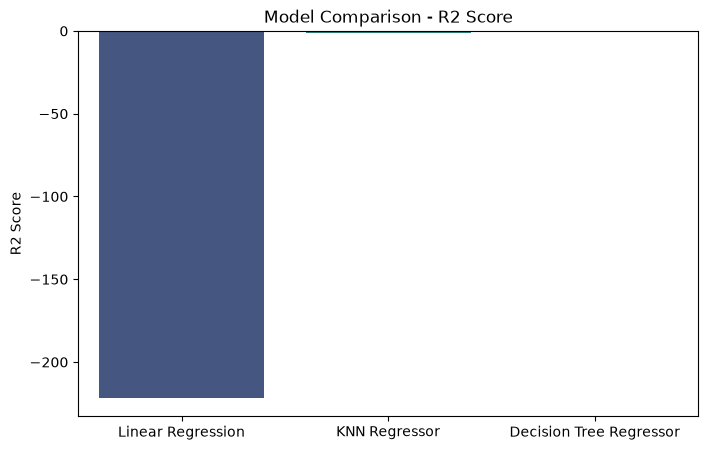

In [468]:
# ==========================================
# 6.6 Comparison Chart
# ==========================================

plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="R2 Score", data=results, hue="Model", palette="viridis", legend=False)
plt.title("Model Comparison - R2 Score")
plt.ylabel("R2 Score")
plt.xlabel("")
plt.show()

In [469]:
# ==========================================
# 6.7 Best Model
# ==========================================

best_model_row = results.loc[results["R2 Score"].idxmax()]
print("Best Model:", best_model_row["Model"])
print("R2 Score:", best_model_row["R2 Score"])

Best Model: Decision Tree Regressor
R2 Score: -0.0015069830592218114


In [470]:
# ==========================================
# 6.8 Best Hyperparameters
# ==========================================

print("Linear Regression: Default Parameters")
print("KNN Regressor:", knn_grid.best_params_)
print("Decision Tree Regressor:", dt_grid.best_params_)

Linear Regression: Default Parameters
KNN Regressor: {'regressor__n_neighbors': 7, 'regressor__weights': 'uniform'}
Decision Tree Regressor: {'regressor__max_depth': 5, 'regressor__min_samples_split': 5}


In [471]:
# ==========================================
# Phase 3
# Deep Learning Regression using TensorFlow
# ==========================================

import tensorflow as tf
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [472]:
# ==========================================
# Build Deep Neural Network
# ==========================================

dnn_model = Sequential([

    Input(shape=(X_train_scaled.shape[1],)),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1)

])

In [473]:
# ==========================================
# Compile Model
# ==========================================

dnn_model.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]

)

In [474]:
# ==========================================
# Early Stopping
# ==========================================

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)

In [475]:
# ==========================================
# Train Model
# ==========================================

# Compile the model before training
dnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = dnn_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4517307904.0000 - mae: 43012.6875 - val_loss: 4331231744.0000 - val_mae: 43532.9102
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4504923136.0000 - mae: 42905.8789 - val_loss: 4296757760.0000 - val_mae: 43241.4180
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4427891200.0000 - mae: 42276.9492 - val_loss: 4146245376.0000 - val_mae: 42045.7656
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4154012928.0000 - mae: 40082.7344 - val_loss: 3667678720.0000 - val_mae: 38189.4219
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3503773184.0000 - mae: 34582.1641 - val_loss: 2785367296.0000 - val_mae: 29971.1895
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2604190208.0000 - mae: 25689.6191 - val_loss: 1950359552.0000 - val_mae: 20866.8105
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2029834624.0000 - mae: 20581.1016 - val_loss: 1615894016.0000 - val_mae: 19100.7676

In [476]:
# ==========================================
# Prediction
# ==========================================

dnn_predictions = dnn_model.predict(X_test_scaled)

# ==========================================
# Evaluation
# ==========================================

dnn_mae = mean_absolute_error(
    y_test,
    dnn_predictions
)

dnn_mse = mean_squared_error(
    y_test,
    dnn_predictions
)

dnn_rmse = np.sqrt(dnn_mse)

dnn_r2 = r2_score(
    y_test,
    dnn_predictions
)

print("="*60)
print("Deep Learning Evaluation")
print("="*60)

print(f"MAE  : {dnn_mae:.2f}")
print(f"RMSE : {dnn_rmse:.2f}")
print(f"R2   : {dnn_r2:.4f}")


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Deep Learning Evaluation
MAE  : 24962.91
RMSE : 137517.09
R2   : 0.0748


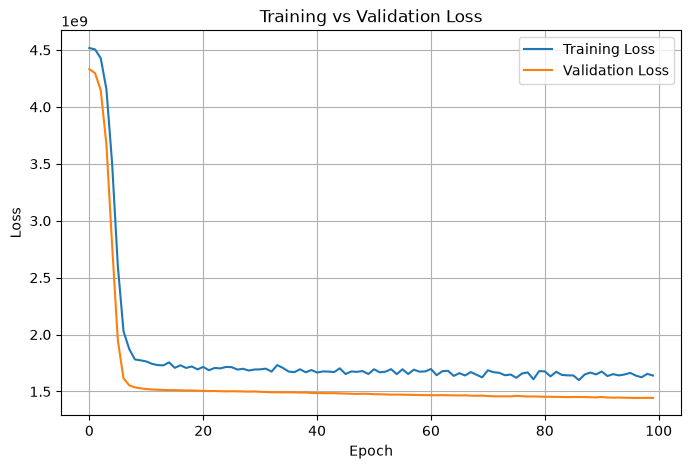

In [477]:
# ==========================================
# Training History
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [478]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "KNN Regressor",
        "Decision Tree Regressor",
        "Deep Learning"
    ],
    "MAE": [
        lr_mae,
        knn_mae,
        dt_mae,
        dnn_mae
    ],
    "RMSE": [
        lr_rmse,
        knn_rmse,
        dt_rmse,
        dnn_rmse
    ],
    "R2 Score": [
        lr_r2,
        knn_r2,
        dt_r2,
        dnn_r2
    ]
})

comparison_df.sort_values(
    by="R2 Score",
    ascending=False,
    inplace=True
)

display(comparison_df.round(4))


,Model,MAE,RMSE,R2 Score
3,Deep Learning,2.496291e+04,1.375171e+05,0.0748
2,Decision Tree Regressor,3.589839e+04,1.430747e+05,-0.0015
1,KNN Regressor,1.755698e+05,2.123184e+05,-1.2055
0,Linear Regression,2.127735e+06,2.132519e+06,-221.4918


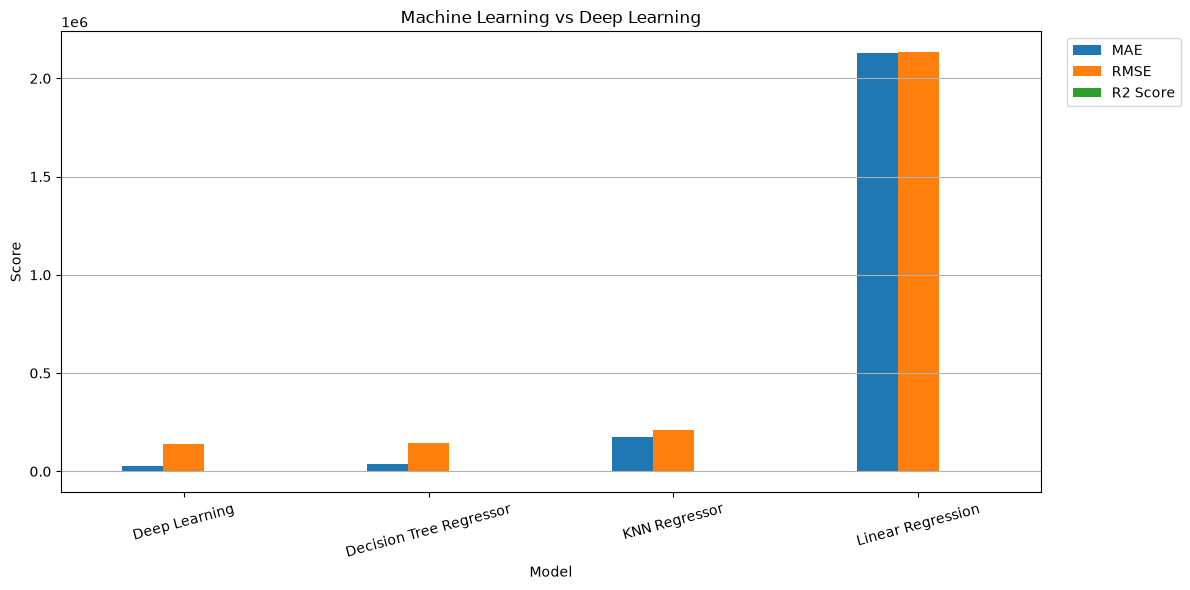

In [479]:
comparison_plot = comparison_df.set_index("Model")

comparison_plot.plot(

    kind="bar",

    figsize=(12,6)

)

plt.title("Machine Learning vs Deep Learning")

plt.ylabel("Score")

plt.xticks(rotation=15)

plt.grid(axis="y")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()